So we have a pretty good model but now we want to perturb it a bit to see if we can do better ie get a better model in terms of out of sample rmse.

In [ ]:
library(IRdisplay)

# Packages are now installed via conda, just load them
library(smooth)
library(forecast)

fdf <- read.csv("data/fluview_clean/ilinet_final.csv")
y <- as.numeric(fdf$age_0_4)


# stopifnot(h < n)



out_of_sample_rmse <- function(data,orders,sse_to_beat = 26) {
    h <- 104
    n <- length(data)
    test_idx <- (n - h + 1):n
    sse <- 0
    previous_fit <- NULL
    for (i in seq_along(test_idx)) {
        t_idx <- test_idx[i]
        train_i <- data[1:(t_idx - 1)]
        fit_i <- msarima(
            train_i,
            model = previous_fit,
            orders = orders,
            lags = c(1, 52, 19),
        )
        previous_fit <- fit_i
        fc_i <- forecast(fit_i, h = 1)
        if (sse > sse_to_beat) {
            return (Inf)
        }
        sse <- sse + (data[t_idx]-fc_i$mean[1])^2
    }
    return (sqrt(sse / h))
}

out_of_sample_rmse(y, orders = list(ar=c(1,0,1), i=c(1,1,0), ma=c(1,0,1)))



[1] 0.09440222

In [16]:
# Now we want a function to vary the orders to see if we can do any better!!

perturb_orders <- function(orders, perturbation) {
    perturbed_orders <- lapply(orders, function(order) {
        order <- as.integer(order)
        order + sample(seq(-perturbation, perturbation), length(order), replace = TRUE)
    })
    perturbed_orders <- lapply(perturbed_orders, function(order) pmax(order, 0))
    names(perturbed_orders) <- names(orders)
    return(perturbed_orders)
}

In [22]:
# so now we can perturb and look for the best rmse
order_string <- function(orders) {
    paste0(
        "ar=", paste(orders$ar, collapse = ","),
        "; i=", paste(orders$i, collapse = ","),
        "; ma=", paste(orders$ma, collapse = ",")
    )
}

find_best_rmse_out_of_sample <- function(data, initial_orders, perturbation, iterations) {
    best_rmse <- out_of_sample_rmse(data, orders = initial_orders)
    current_orders <- initial_orders
    best_sse <- best_rmse^2 * 104  # Convert RMSE back to SSE for comparison
    for (i in 1:iterations) {
        new_orders <- perturb_orders(current_orders, perturbation)
        rmse <- out_of_sample_rmse(data, orders = new_orders,sse_to_beat = best_sse)
        # display_text(paste("Processing iteration:", i))
        
        if (rmse < best_rmse) {
            best_rmse <- rmse
            current_orders <- new_orders
        }
        
        display_text(paste("Iteration:", i, "Perturbed Orders:", order_string(new_orders), "RMSE:", rmse, "\n"))
    }
    
    return(list(best_orders = current_orders, best_rmse = best_rmse))
}

value <- find_best_rmse_out_of_sample(
  y,
  initial_orders = list(ar = c(1, 0, 1), i = c(1, 1, 0), ma = c(1, 0, 1)),
  perturbation = 1,
  iterations = 10
 )

print(value)

Iteration: 1 Perturbed Orders: ar=2,1,0; i=2,1,0; ma=0,0,1 RMSE: Inf 


Iteration: 2 Perturbed Orders: ar=0,1,1; i=0,0,1; ma=1,0,1 RMSE: Inf 


Iteration: 3 Perturbed Orders: ar=2,0,1; i=2,0,1; ma=1,1,2 RMSE: Inf 


Iteration: 4 Perturbed Orders: ar=0,0,0; i=0,2,1; ma=1,0,2 RMSE: Inf 


Iteration: 5 Perturbed Orders: ar=1,0,2; i=2,2,0; ma=2,0,2 RMSE: Inf 


...

Iteration: 7 Perturbed Orders: ar=1,0,1; i=0,1,0; ma=0,0,2 RMSE: Inf 


Iteration: 8 Perturbed Orders: ar=0,0,3; i=1,1,0; ma=0,0,1 RMSE: Inf 


Iteration: 9 Perturbed Orders: ar=2,0,3; i=0,1,0; ma=0,0,2 RMSE: Inf 


Iteration: 10 Perturbed Orders: ar=0,1,2; i=0,1,1; ma=1,0,3 RMSE: Inf 


$best_orders
$best_orders$ar
[1] 1 0 2

$best_orders$i
[1] 0 1 0

$best_orders$ma
[1] 0 0 2


$best_rmse
[1] 0.09109648



In [ ]:
# varmarima(y, order = c(1, 0, 1), seasonal = list(order = c(1, 1, 0), period = 52))
ARIMAX()


,X,ilitotal,percent_weighted_ili,percent_unweighted_ili,pw_trans,puw_trans,year,week,age_0_4,age_5_24,age_25_64,age_65,num_of_providers,non_ilitotal
,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,570,1.10148,1.21686,-4.409528,-4.316664,1997,40,5.192957,5.327876,5.062595,3.401197,5.262690,10.74231
2,2,615,1.20007,1.28064,-4.329666,-4.268720,1997,41,5.298317,5.493061,5.023881,3.178054,5.257495,10.76657
3,3,681,1.37876,1.23906,-4.199068,-4.299721,1997,42,5.433722,5.587249,5.036953,3.555348,5.393628,10.90193
4,4,653,1.19920,1.14473,-4.330344,-4.373726,1997,43,5.241747,5.468060,5.267858,3.610918,5.365976,10.94008
5,5,700,1.65618,1.26112,-4.024311,-4.283158,1997,44,5.384495,5.638355,5.093750,3.737670,5.365976,10.91157
6,6,655,1.41326,1.28275,-4.175656,-4.267172,1997,45,5.187386,5.641907,5.003946,3.891820,5.278115,10.82791


,X,ili_total,percent_weighted_ili,percent_unweighted_ili,pw_trans,puw_trans,year,week,age_0_4,age_5_24,age_25_64,age_65,num_of_providers,non_ilitotal
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,6.347389,1.10148,1.21686,-4.409528,-4.316664,1997,40,5.192957,5.327876,5.062595,3.401197,5.262690,10.74231
2,2,6.423247,1.20007,1.28064,-4.329666,-4.268720,1997,41,5.298317,5.493061,5.023881,3.178054,5.257495,10.76657
3,3,6.525030,1.37876,1.23906,-4.199068,-4.299721,1997,42,5.433722,5.587249,5.036953,3.555348,5.393628,10.90193
4,4,6.483107,1.19920,1.14473,-4.330344,-4.373726,1997,43,5.241747,5.468060,5.267858,3.610918,5.365976,10.94008
5,5,6.552508,1.65618,1.26112,-4.024311,-4.283158,1997,44,5.384495,5.638355,5.093750,3.737670,5.365976,10.91157
6,6,6.486161,1.41326,1.28275,-4.175656,-4.267172,1997,45,5.187386,5.641907,5.003946,3.891820,5.278115,10.82791


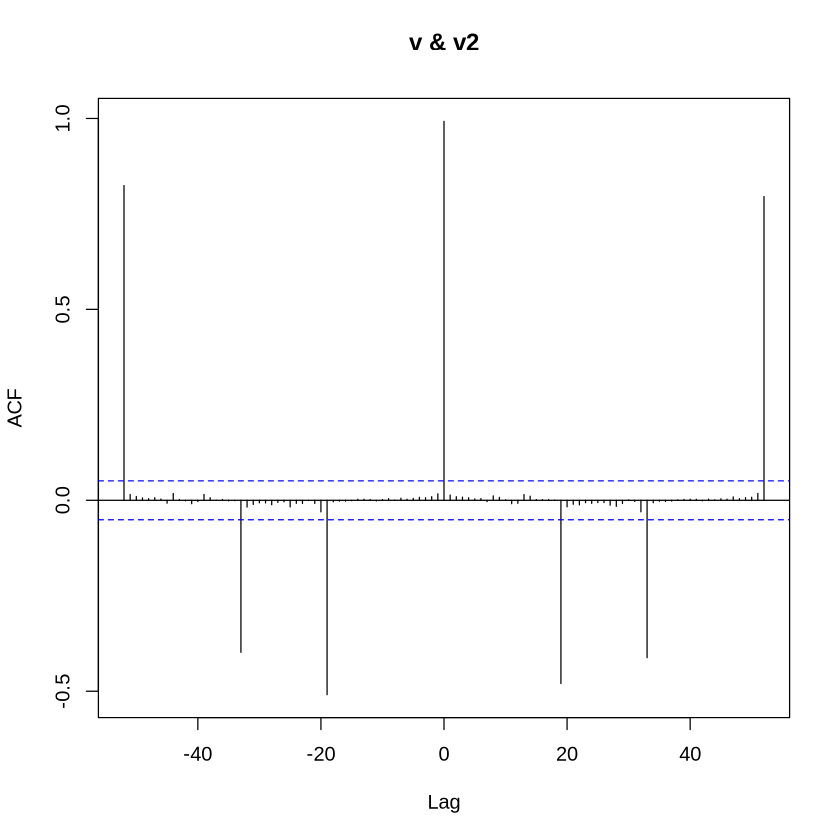

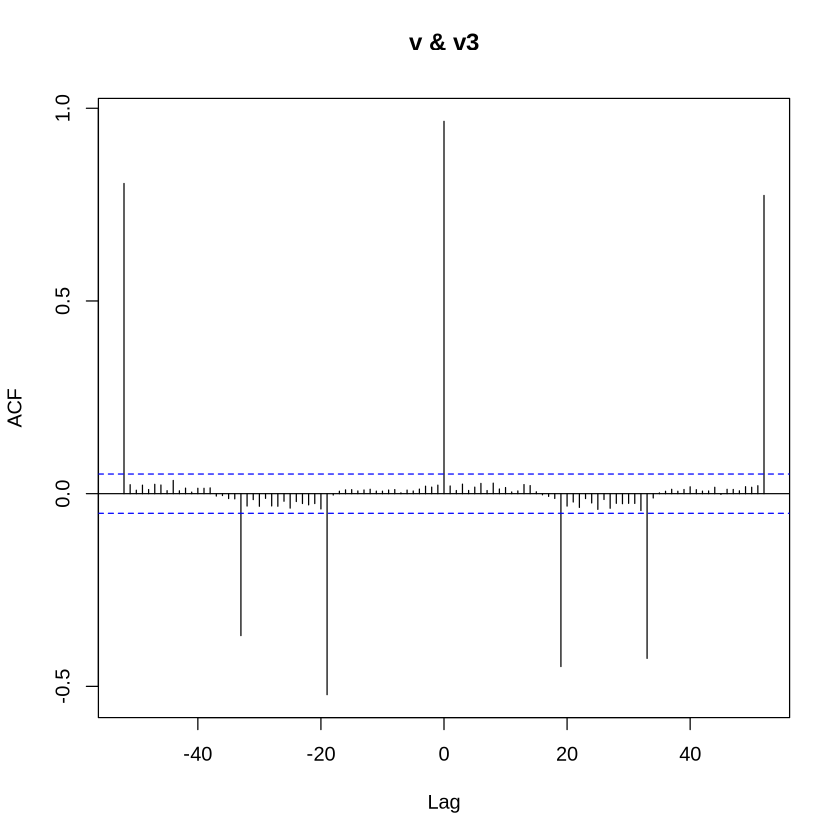

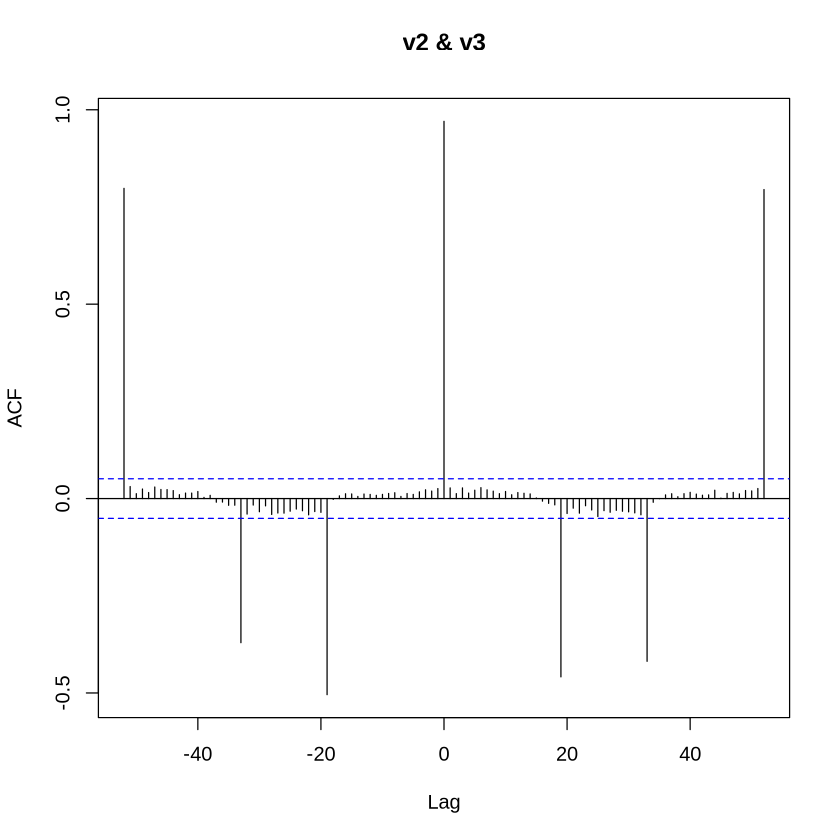

In [35]:
v <- diff(fdf$non_ilitotal)
head(fdf)
v2 <- diff(fdf$num_of_providers)
ccf(v, v2, lag.max = 52)
v3 <- diff(fdf$ili_total)
    ccf(v, v3, lag.max = 52)
    ccf(v2, v3, lag.max = 52)





In [ ]:
# varma model for non_ilitotal, num_of_providers, and ili_total


Warning message in adf.test(x):
“p-value smaller than printed p-value”
Warning message in adf.test(x):
“p-value smaller than printed p-value”


Warning message in adf.test(x):
“p-value smaller than printed p-value”


[1] "ADF test p-values (stationarity):"
$non_ilitotal
[1] 0.01

$num_of_providers
[1] 0.01

$ili_total
[1] 0.01



Warning message in adf.test(x):
“p-value smaller than printed p-value”
Warning message in adf.test(x):
“p-value smaller than printed p-value”
Warning message in adf.test(x):
“p-value smaller than printed p-value”


[1] "ADF test p-values after seasonal differencing (lag 52):"
$non_ilitotal
[1] 0.01

$num_of_providers
[1] 0.01

$ili_total
[1] 0.01



Warning message in adf.test(x):
“p-value smaller than printed p-value”
Warning message in adf.test(x):
“p-value smaller than printed p-value”
Warning message in adf.test(x):
“p-value smaller than printed p-value”


[1] "Final ADF test p-values:"
$non_ilitotal
[1] 0.01

$num_of_providers
[1] 0.01

$ili_total
[1] 0.01

[1] "Cross-correlations at lag 19:"


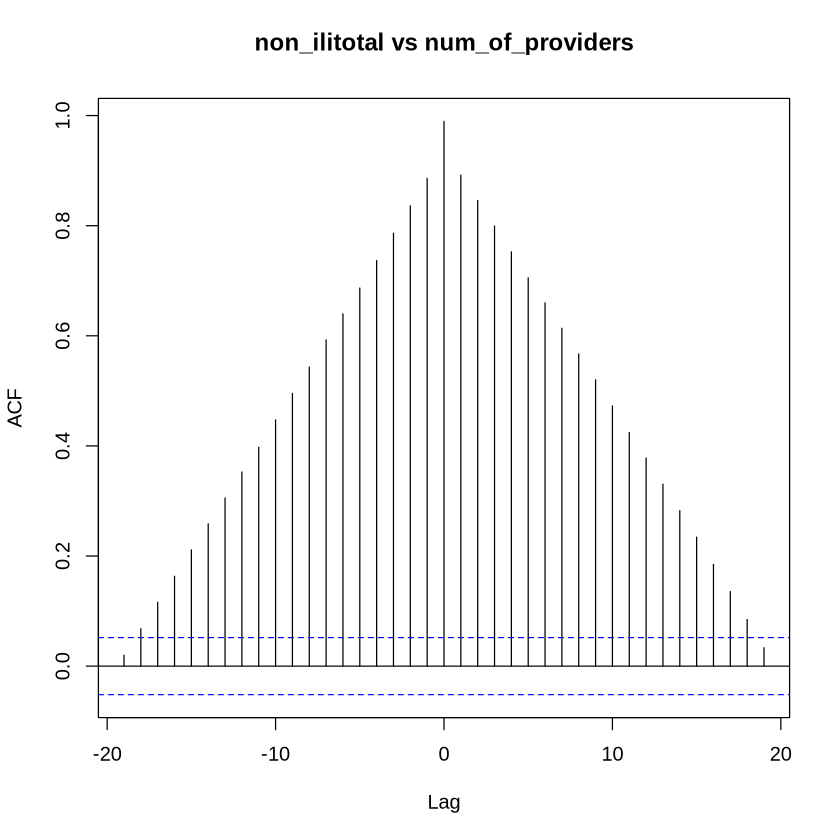

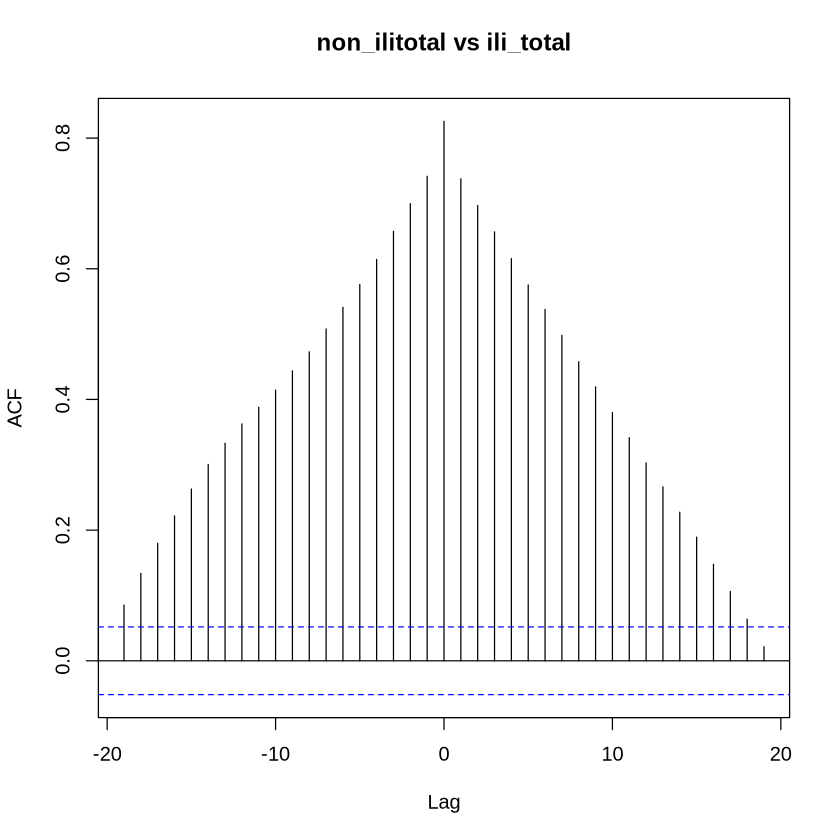

[1] "Johansen cointegration test:"

###################### 
# Johansen-Procedure # 
###################### 

Test type: trace statistic , with linear trend 

Eigenvalues (lambda):
[1] 0.043652238 0.040797419 0.008992809

Values of teststatistic and critical values of test:

           test 10pct  5pct  1pct
r <= 2 |  13.37  6.50  8.18 11.65
r <= 1 |  75.02 15.66 17.95 23.52
r = 0  | 141.07 28.71 31.52 37.22

Eigenvectors, normalised to first column:
(These are the cointegration relations)

                    non_ilitotal.l2 num_of_providers.l2 ili_total.l2
non_ilitotal.l2            1.000000            1.000000    1.0000000
num_of_providers.l2       -1.825969           -4.317360   -1.6960510
ili_total.l2               0.130816            1.850398   -0.3798424

Weights W:
(This is the loading matrix)

                   non_ilitotal.l2 num_of_providers.l2 ili_total.l2
non_ilitotal.d          -0.4369796          0.07348038   0.02531177
num_of_providers.d      -0.2107297          0.04207

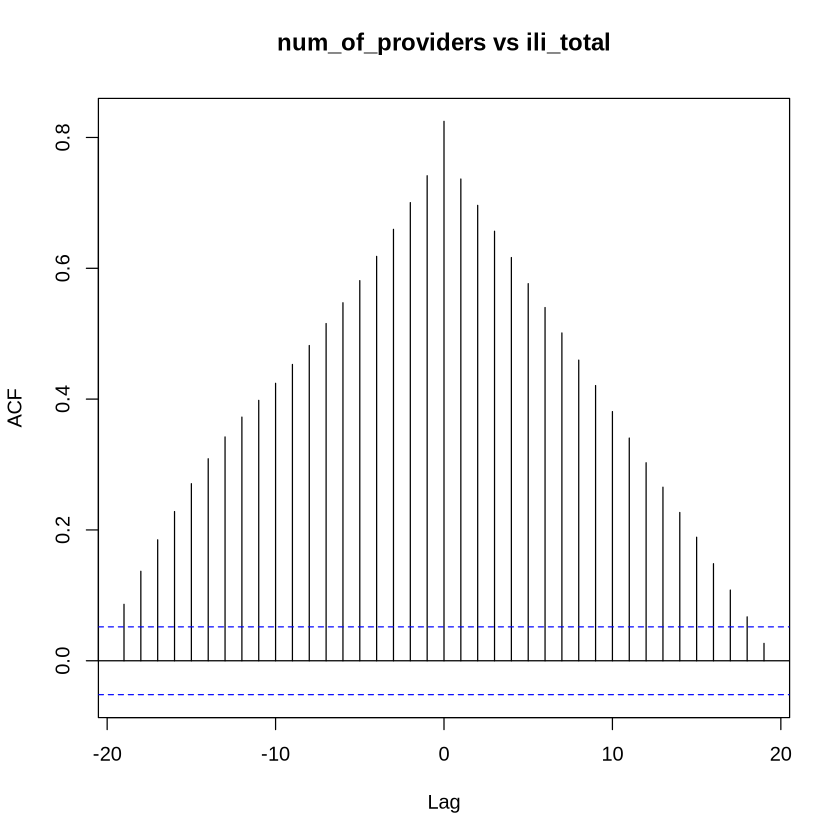

In [47]:
# VARMA model for non_ilitotal, num_of_providers, and ili_total
# Taking into account differencing and seasonal lags at 19 and 52

# Load required packages
library(MTS)  # For VARMA models
library(urca)  # For cointegration tests
library(tseries)  # For stationarity tests
library(forecast)  # For auto.arima

# Prepare the multivariate data
vars_data <- fdf[, c("non_ilitotal", "num_of_providers", "ili_total")]
vars_data <- na.omit(vars_data)  # Remove any NA values

# Check for stationarity and apply differencing if needed
adf_tests <- lapply(vars_data, function(x) adf.test(x)$p.value)
print("ADF test p-values (stationarity):")
print(adf_tests)

# Apply seasonal differencing at lag 52 (weekly seasonality)
vars_seasonal_diff <- apply(vars_data, 2, function(x) diff(x, lag = 52))
vars_seasonal_diff <- as.data.frame(vars_seasonal_diff)

# Check stationarity after seasonal differencing
adf_tests_seasonal <- lapply(vars_seasonal_diff, function(x) adf.test(x)$p.value)
print("ADF test p-values after seasonal differencing (lag 52):")
print(adf_tests_seasonal)

# If still not stationary, apply first differencing
if(any(unlist(adf_tests_seasonal) > 0.05)) {
  vars_diff <- apply(vars_seasonal_diff, 2, diff)
  vars_diff <- as.data.frame(vars_diff)
  print("Applied additional first differencing")
} else {
  vars_diff <- vars_seasonal_diff
}

# Final stationarity check
adf_tests_final <- lapply(vars_diff, function(x) adf.test(x)$p.value)
print("Final ADF test p-values:")
print(adf_tests_final)

# Cross-correlation analysis to identify lags
print("Cross-correlations at lag 19:")
ccf(vars_diff$non_ilitotal, vars_diff$num_of_providers, lag.max = 19, main = "non_ilitotal vs num_of_providers")
ccf(vars_diff$non_ilitotal, vars_diff$ili_total, lag.max = 19, main = "non_ilitotal vs ili_total")
ccf(vars_diff$num_of_providers, vars_diff$ili_total, lag.max = 19, main = "num_of_providers vs ili_total")

# Check for cointegration
coint_test <- ca.jo(vars_data, type = "trace", K = 2)
print("Johansen cointegration test:")
print(summary(coint_test))

# Fit VAR model (simpler than VARMA for initial analysis)
var_model <- vars::VAR(vars_diff, p = 1, type = "const")
print("VAR model summary:")
print(summary(var_model))

# Alternatively, fit separate SARIMA models with exogenous variables
# This accounts for the relationships between variables
xreg_matrix <- as.matrix(vars_data[, c("num_of_providers", "ili_total")])

sarima_non_ili <- auto.arima(vars_data$non_ilitotal,
                            xreg = xreg_matrix,
                            seasonal = TRUE,
                            stepwise = FALSE,
                            approximation = FALSE)

xreg_matrix_providers <- as.matrix(vars_data[, c("non_ilitotal", "ili_total")])
sarima_providers <- auto.arima(vars_data$num_of_providers,
                              xreg = xreg_matrix_providers,
                              seasonal = TRUE,
                              stepwise = FALSE,
                              approximation = FALSE)

xreg_matrix_ili <- as.matrix(vars_data[, c("non_ilitotal", "num_of_providers")])
sarima_ili <- auto.arima(vars_data$ili_total,
                        xreg = xreg_matrix_ili,
                        seasonal = TRUE,
                        stepwise = FALSE,
                        approximation = FALSE)

print("SARIMA with exogenous variables - non_ilitotal:")
print(sarima_non_ili)

print("SARIMA with exogenous variables - num_of_providers:")
print(sarima_providers)

print("SARIMA with exogenous variables - ili_total:")
print(sarima_ili)

In [48]:
# write a model selection function that perturbs each one of the variables to try and better predict them...
# specifically, age_0_4	age_5_24	age_25_64	age_65. Then save each converged output to a txt file and an object so it is useable later in the analysis. 
head(fdf)

,X,ili_total,percent_weighted_ili,percent_unweighted_ili,pw_trans,puw_trans,year,week,age_0_4,age_5_24,age_25_64,age_65,num_of_providers,non_ilitotal
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,6.347389,1.10148,1.21686,-4.409528,-4.316664,1997,40,5.192957,5.327876,5.062595,3.401197,5.262690,10.74231
2,2,6.423247,1.20007,1.28064,-4.329666,-4.268720,1997,41,5.298317,5.493061,5.023881,3.178054,5.257495,10.76657
3,3,6.525030,1.37876,1.23906,-4.199068,-4.299721,1997,42,5.433722,5.587249,5.036953,3.555348,5.393628,10.90193
4,4,6.483107,1.19920,1.14473,-4.330344,-4.373726,1997,43,5.241747,5.468060,5.267858,3.610918,5.365976,10.94008
5,5,6.552508,1.65618,1.26112,-4.024311,-4.283158,1997,44,5.384495,5.638355,5.093750,3.737670,5.365976,10.91157
6,6,6.486161,1.41326,1.28275,-4.175656,-4.267172,1997,45,5.187386,5.641907,5.003946,3.891820,5.278115,10.82791


In [42]:
# Model selection function that perturbs each age group variable
# Saves converged outputs to txt files and R objects

# Define the age group variables to model
# "age_0_4", "age_5_24", "age_25_64"
age_groups <- c("age_25_64","age_65")

# Function to run perturbation search for a single age group
run_age_group_perturbation <- function(age_var, initial_orders, perturbation = 1, iterations = 50) {

    display_text(paste("Starting perturbation search for", age_var, "with initial orders:", order_string(initial_orders), "\n"))
    # Get the data for this age group
    y <- as.numeric(fdf[[age_var]])

    # Remove any NA values
    y <- na.omit(y)

    # Run the perturbation search
    result <- find_best_rmse_out_of_sample(
        data = y,
        initial_orders = initial_orders,
        perturbation = perturbation,
        iterations = iterations
    )

    # Add metadata to the result
    result$age_group <- age_var
    result$data_length <- length(y)
    result$search_params <- list(
        initial_orders = initial_orders,
        perturbation = perturbation,
        iterations = iterations
    )

    cat("Best RMSE for", age_var, ":", result$best_rmse, "\n")
    cat("Best orders:", order_string(result$best_orders), "\n")

    return(result)
}

# Function to run perturbation for all age groups and save results
run_all_age_groups_perturbation <- function(initial_orders_list = NULL, perturbation = 1, iterations = 50) {

    # Default initial orders for each age group (can be customized)
    if (is.null(initial_orders_list)) {
        initial_orders_list <- list(
            age_0_4 = list(ar = c(1, 0, 1), i = c(1, 1, 0), ma = c(1, 0, 1)),
            age_5_24 = list(ar = c(1, 0, 1), i = c(1, 1, 0), ma = c(1, 0, 1)),
            age_25_64 = list(ar = c(1, 0, 1), i = c(1, 1, 0), ma = c(1, 0, 1)),
            age_65 = list(ar = c(1, 0, 1), i = c(1, 1, 0), ma = c(1, 0, 1))
        )
    }

    # Create results directory if it doesn't exist
    results_dir <- "model_results"
    if (!dir.exists(results_dir)) {
        dir.create(results_dir)
    }

    # Store all results
    all_results <- list()

    # Run perturbation for each age group
    for (age_var in age_groups) {
        if (age_var %in% names(initial_orders_list)) {
            result <- run_age_group_perturbation(
                age_var = age_var,
                initial_orders = initial_orders_list[[age_var]],
                perturbation = perturbation,
                iterations = iterations
            )

            # Store result
            all_results[[age_var]] <- result

            # Save to txt file
            txt_filename <- file.path(results_dir, paste0("msarima_", age_var, "_results.txt"))
            sink(txt_filename)
            cat("MSARIMA Model Results for", age_var, "\n")
            cat("=====================================\n\n")
            cat("Best RMSE:", result$best_rmse, "\n")
            cat("Best Orders - AR:", paste(result$best_orders$ar, collapse = ","), "\n")
            cat("Best Orders - I:", paste(result$best_orders$i, collapse = ","), "\n")
            cat("Best Orders - MA:", paste(result$best_orders$ma, collapse = ","), "\n")
            cat("Data Length:", result$data_length, "\n")
            cat("Search Parameters:\n")
            cat("  Initial Orders - AR:", paste(result$search_params$initial_orders$ar, collapse = ","), "\n")
            cat("  Initial Orders - I:", paste(result$search_params$initial_orders$i, collapse = ","), "\n")
            cat("  Initial Orders - MA:", paste(result$search_params$initial_orders$ma, collapse = ","), "\n")
            cat("  Perturbation:", result$search_params$perturbation, "\n")
            cat("  Iterations:", result$search_params$iterations, "\n")
            sink()

            # Save R object
            rds_filename <- file.path(results_dir, paste0("msarima_", age_var, "_model.rds"))
            saveRDS(result, file = rds_filename)

            cat("Results saved to:", txt_filename, "and", rds_filename, "\n")
        } else {
            warning("No initial orders specified for", age_var)
        }
    }

    # Save summary of all results
    summary_filename <- file.path(results_dir, "all_age_groups_summary.txt")
    sink(summary_filename)
    cat("MSARIMA Model Selection Summary for All Age Groups\n")
    cat("==================================================\n\n")
    cat("Search Parameters:\n")
    cat("Perturbation:", perturbation, "\n")
    cat("Iterations:", iterations, "\n\n")

    cat("Results Summary:\n")
    for (age_var in names(all_results)) {
        result <- all_results[[age_var]]
        cat(age_var, ":\n")
        cat("  Best RMSE:", result$best_rmse, "\n")
        cat("  Best Orders:", order_string(result$best_orders), "\n")
        cat("  Data Points:", result$data_length, "\n\n")
    }
    sink()

    # Save all results as single R object
    all_results_filename <- file.path(results_dir, "all_age_groups_results.rds")
    saveRDS(all_results, file = all_results_filename)

    cat("\nAll results saved to model_results/ directory\n")
    cat("Summary file:", summary_filename, "\n")
    cat("Combined R object:", all_results_filename, "\n")

    return(all_results)
}

# Run the model selection for all age groups
cat("Starting comprehensive model selection for all age groups...\n")
all_age_results <- run_all_age_groups_perturbation(
    perturbation = 2,
    iterations = 50  # Start with fewer iterations for testing
)

# Display summary
cat("\n=== FINAL SUMMARY ===\n")
for (age_var in names(all_age_results)) {
    result <- all_age_results[[age_var]]
    cat(age_var, "- Best RMSE:", result$best_rmse,
        "Orders:", order_string(result$best_orders), "\n")
}

Starting comprehensive model selection for all age groups...


Starting perturbation search for age_25_64 with initial orders: ar=1,0,1; i=1,1,0; ma=1,0,1 


Iteration: 1 Perturbed Orders: ar=3,0,3; i=0,0,0; ma=3,0,0 RMSE: Inf 


Iteration: 2 Perturbed Orders: ar=0,0,0; i=3,1,0; ma=2,0,0 RMSE: Inf 


Iteration: 3 Perturbed Orders: ar=0,0,0; i=0,3,1; ma=0,0,3 RMSE: Inf 


...

Iteration: 16 Perturbed Orders: ar=3,2,1; i=1,1,0; ma=1,0,0 RMSE: Inf 


Iteration: 17 Perturbed Orders: ar=3,0,0; i=0,3,0; ma=1,1,0 RMSE: Inf 


Iteration: 18 Perturbed Orders: ar=0,0,0; i=2,3,0; ma=0,2,1 RMSE: Inf 


Best RMSE for age_25_64 : 0.093035 
Best orders: ar=0,1,0; i=2,1,0; ma=2,2,0 
Results saved to: model_results/msarima_age_25_64_results.txt and model_results/msarima_age_25_64_model.rds 


ERROR: Error in sum(sapply(arma, length)): invalid 'type' (list) of argument


Warning message in plot.window(...):
“"max.lag" is not a graphical parameter”
Warning message in plot.xy(xy, type, ...):
“"max.lag" is not a graphical parameter”
Warning message in axis(side = side, at = at, labels = labels, ...):
“"max.lag" is not a graphical parameter”
Warning message in axis(side = side, at = at, labels = labels, ...):
“"max.lag" is not a graphical parameter”
Warning message in box(...):
“"max.lag" is not a graphical parameter”
Warning message in title(...):
“"max.lag" is not a graphical parameter”
Warning message in doTryCatch(return(expr), name, parentenv, handler):
“"max.lag" is not a graphical parameter”
Warning message in doTryCatch(return(expr), name, parentenv, handler):
“"max.lag" is not a graphical parameter”
Warning message in doTryCatch(return(expr), name, parentenv, handler):
“"max.lag" is not a graphical parameter”
Warning message in doTryCatch(return(expr), name, parentenv, handler):
“"max.lag" is not a graphical parameter”
Warning message in doTryCatc

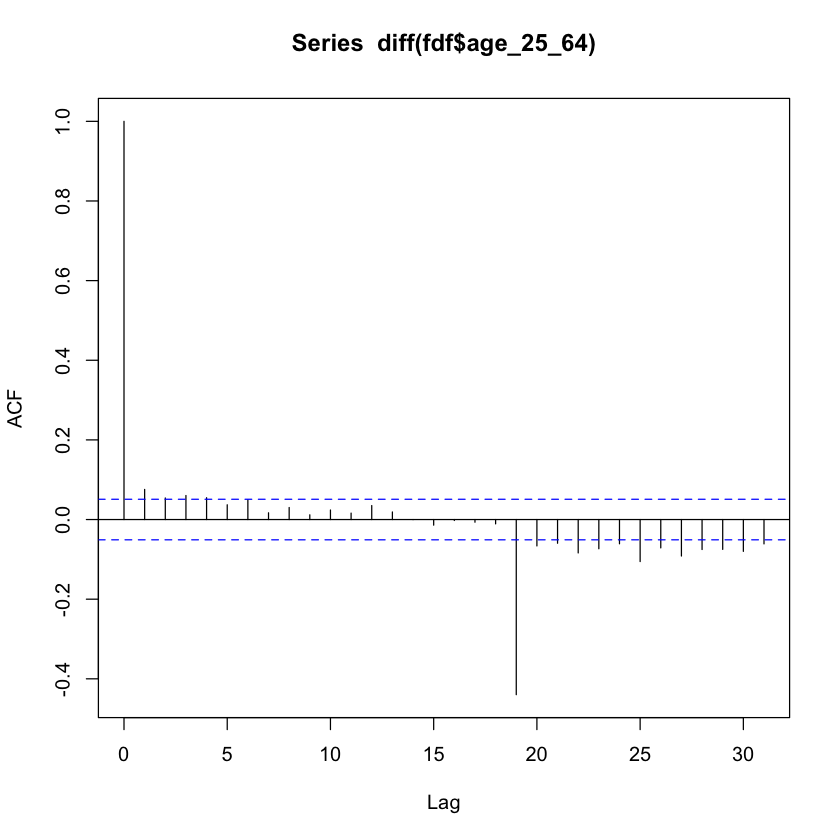

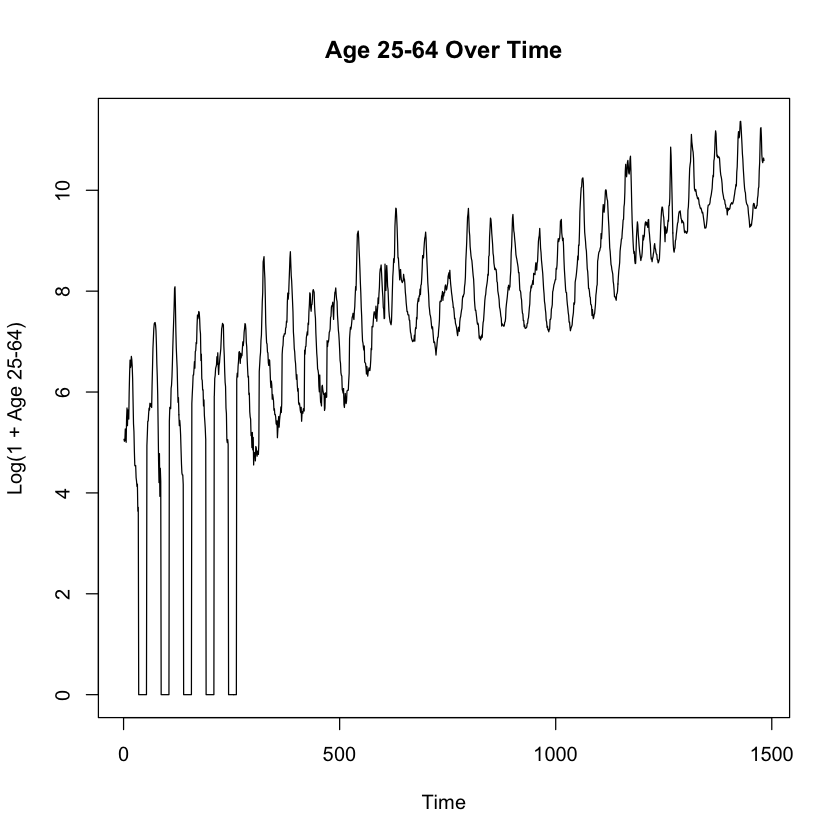

Warning message in plot.window(...):
“"max.lag" is not a graphical parameter”
Warning message in plot.xy(xy, type, ...):
“"max.lag" is not a graphical parameter”
Warning message in axis(side = side, at = at, labels = labels, ...):
“"max.lag" is not a graphical parameter”
Warning message in axis(side = side, at = at, labels = labels, ...):
“"max.lag" is not a graphical parameter”
Warning message in box(...):
“"max.lag" is not a graphical parameter”
Warning message in title(...):
“"max.lag" is not a graphical parameter”


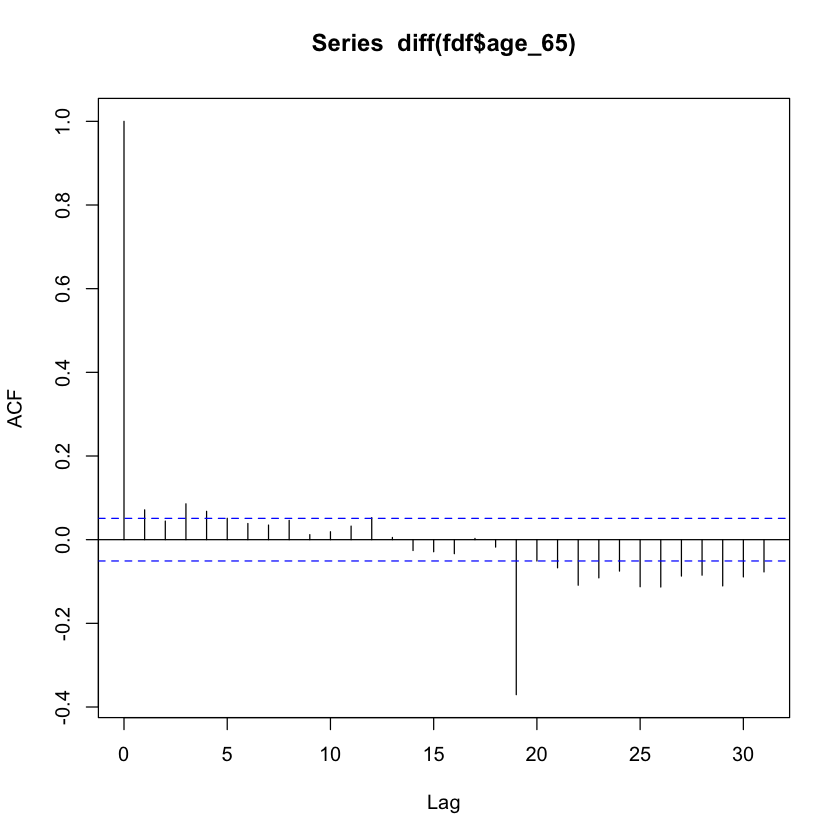

In [ ]:
# acf(diff(fdf$age_25_64),max.lag=52)
# fdf <- read.csv("data/fluview_clean/ilinet_final.csv")
# plot(fdf$age_25_64, type = "l", main = "Age 25-64 Over Time", xlab = "Time", ylab = "Log(1 + Age 25-64)")
# acf(diff(fdf$age_65),max.lag=52)